# 从单目标检测 → 多目标检测

## 回顾：我们现在的做法

```
单目标检测（当前 Net）:
输入 (3,300,300) → 特征提取 → Flatten → Linear(512,5) → 输出 (B,5)
                                                              ├── x1, y1, x2, y2 (归一化坐标)
                                                              └── conf (有无目标的置信度)
```

**问题**：整个图只输出 **1 个框**。如果图里有多个小黄人，模型只能"选一个"或者"乱猜"。

---

## 多目标检测的核心思路

多目标检测要回答两个问题：
1. **哪里可能有目标？** → 先提出一些候选区域
2. **这些区域里是什么？** → 对每个候选区做分类 + 框回归

主要有三类方法：

---

### 方案一：两阶段检测器 (Two-Stage)

代表作：**Faster R-CNN**

```
Step 1: 主干网络提取特征 → RPN（区域提议网络）→ 生成若干候选框（region proposals）
Step 2: 对每个候选框 → RoI Pooling 缩放到统一尺寸 → 分类 + 框回归
```

**优点**：精度高，适合小目标  
**缺点**：速度慢，结构复杂

```
输入 → CNN特征图 → RPN → 候选框 → RoI Pooling → 分类+回归
                ↓                          ↓
           "这里可能有目标"           "是啥 + 框调准"
```

---

### 方案二：单阶段检测器 (One-Stage)

代表作：**YOLO**、**SSD**

#### 核心思想：把检测当成"回归问题"一步到位

**YOLO 的思路**（跟我们的 FullyConvNetV2 很像！）：

```
将图片划分成 S×S 的 Grid（例如 7×7）

每个 Grid Cell 负责预测：
  ├── B 个边界框（每个框: x, y, w, h, conf）
  └── C 个类别概率（人、车、猫...）

输出张量形状: (S, S, B×5 + C)
```

```
输入图像
  │
  └─→ CNN 特征提取器（全卷积，保留空间 Grid）
        │
        └─→ 输出特征图 (S, S, B×5+C)
               │
               ├── Cell(0,0) → [框1, 框2, 类别概率...]
               ├── Cell(0,1) → [框1, 框2, 类别概率...]
               └── ... 共 S×S 个 Cell
```

**YOLO 的核心规则**：
- 目标中心落在哪个 Grid Cell，就由那个 Cell 负责检测
- 每个 Cell 预测 B 个框，每个框有 **5 个值** `(x, y, w, h, confidence)`
- 推理时用 **NMS（非极大值抑制）** 合并重复框

---

### 方案三：基于 Transformer（最新）

代表作：**DETR**（Detection Transformer）

> 把检测当成"集合预测问题"——直接用 Transformer 输出一组框，不需要 NMS

---

## 从单目标到多目标——我们的代码需要改什么？

假设我们要做一个**简易多目标检测器**（类 YOLO 风格）：

### 1. 网络结构改动

```python
# 当前 - 单目标（输出 1 个框）
out = Linear(512, 5)          → (B, 5)

# 多目标（输出 S×S 个 Grid 预测，每个 Grid B 个框）
out = Conv2d(512, B×5, 1)     → (B, B×5, S, S)
```

- 保留 `FullyConvNetV2` 的 Grid 结构（例如 9×9）
- 每个 Grid Cell 预测 **B 个框**（B≥1，通常 2~3 个）
- 每个框 5 个值：`(tx, ty, tw, th, conf)` — 注意坐标编码方式不同

### 2. 标签分配（最关键的变化）

**单目标**：整个图只有 1 个目标 → 1 个 ground truth 框

**多目标**：
```
图片里有 N 个目标（小黄人A、小黄人B...）
每个目标要分配给一个 Grid Cell 负责：
  → 目标中心落在哪个 Cell，就由哪个 Cell 负责
  → 如果 B>1，选择 IoU 最大的那个框来负责
```

```python
# 伪代码：标签分配
for 每个目标 gt_box in image:
    # 1. 计算中心坐标
    cx, cy = (gt_box.x1 + gt_box.x2) / 2, (gt_box.y1 + gt_box.y2) / 2
    # 2. 找到对应的 Grid Cell
    cell_row = int(cy / grid_size)
    cell_col = int(cx / grid_size)
    # 3. 这个 Cell 负责预测该目标
    # 其余 Cell 的 conf = 0（无目标）
```

### 3. Loss 计算变化

```python
# 当前
loss = cls_loss(conf_pred, labels) + reg_loss(bbox_pred[pos], bbox_gt[pos])

# 多目标 → 需要处理"正负样本不平衡"
# 负样本（无目标 Cell）远多于正样本（有目标 Cell）

loss = λ_coord × reg_loss(正样本框)    # 只算正样本的回归
     + λ_obj   × cls_loss(正样本conf)   # 正样本的置信度 → 1
     + λ_noobj × cls_loss(负样本conf)   # 负样本的置信度 → 0（压低）
```

### 4. 后处理：NMS（非极大值抑制）

多目标检测器会输出**很多重叠的框**，需要用 NMS 过滤：

```
NMS 算法:
1. 按置信度排序所有框
2. 选置信度最高的框，保留它
3. 去掉和它 IoU > 阈值（如 0.5）的其他框
4. 重复直到所有框都处理完
```

```
NMS 示例（阈值 0.5）:
  ┌────────┐  conf=0.92  ──→ ✅ 保留（最高分）
  └────────┘
  ┌────────┐  conf=0.85  ──→ ❌ 去掉（与保留框 IoU=0.78 > 0.5）
  └────────┘
           ┌──┐  conf=0.73  ──→ ✅ 保留（与前面框不重叠）
           └──┘
```

---

## 总结对比

| | 单目标检测（当前） | 多目标检测 |
|---|---|---|
| 输出 | 1 个框 (B,5) | S×S 个 Cell，每个 B 个框 |
| Grid 空间 | 可要可不要 | **必须保留 Grid** |
| 标签分配 | 整图一个 label | 每个目标分配给一个 Cell |
| 正负样本 | 平衡（一半正一半负） | **严重不平衡** → 需要 Focal Loss 或权重 |
| 后处理 | 不需要 | **NMS** 合并重复框 |
| 实现难度 | ⭐ | ⭐⭐⭐⭐⭐ |

---

## 建议学习路线

```
1️⃣ 理解 YOLOv1 论文（最简方案）
    └── 我们的 FullyConvNetV2 已经接近 YOLOv1 的雏形！

2️⃣ 在当前 V2 基础上改：
    ├── Grid Cell 输出 B 个框（B=2）
    ├── 实现标签分配逻辑
    └── 加上 NMS 后处理

3️⃣ 升级到 YOLOv3 / v5+
    ├── 多尺度预测（FPN）
    ├── Anchor Box（先验框）
    └── 数据增强（Mosaic, MixUp...）
```

> **一句话**：多目标检测 ≈ **Grid + 每个 Cell 多个框 + 标签分配 + NMS**，而我们已有的 `FullyConvNetV2` 已经有了 Grid 结构，离 YOLO 只有一步之遥！🚀


单类单目标拓展到多类多目标的思路推导

- 单类单目标输出结构：单类单目标的输出为n×5，5个值分别是x1、y1、x2、y2和置信度，对应二分类判断是否存在目标。
- 多类单目标改造方法：如果是5分类，需要在4个坐标后增加5个one hot格式的类别输出，最终输出维度为n×(4+5)=n×9，对类别输出做softmax将值归一化到0~1之间得到概率。
- 多类多目标改造限制：如果直接增加维度实现多类多目标，会出现坐标归属无法判断、one hot只能输出一个类的问题，原有网络架构无法实现多类多目标检测，因此需要引入YOLO算法。

YOLO算法核心设计思路

- YOLO全称与核心思想：YOLO全称You Only Look Once，是端到端的目标检测算法，将目标检测当成回归问题处理，输入一张图直接输出所有目标的位置与类别，只需要一次前向推理即可得到所有结果。
- 坐标表达方法调整：YOLO将原来的左上角+右下角坐标（x1,y1,x2,y2）改为中心点+宽高（cx,cy,w,h），中心点和宽高是解耦的，分开预测，降低耦合度提升网络拟合效果。
- 网格划分策略：将输入416×416的原图等分为S×S个网格，这里S默认取13，得到13×13的特征图，每个网格负责预测中心点落在该网格内的目标。
- 卷积位置相关性原理：原图经过卷积下采样32倍后，416×416变为13×13，原始目标的空间位置不会发生变化，原图左上角的目标下采样后依旧在特征图的左上角，可直接通过位置对应关系映射。

YOLO特征图通道含义解析

- 通道分配规则：每个网格对应特征图的多个通道，通道顺序依次为：置信度（1个通道，判断是否存在目标）、cx（1个通道）、cy（1个通道）、w（1个通道）、h（1个通道）、分类one hot通道（分类数对应N个通道），如果是6分类总共有1+4+6=11个通道。
- 多目标特征图赋值逻辑：两个目标中心点落在不同网格，就在对应通道的对应位置赋值，比如第一个目标类别为猫（第0类），就在猫对应通道对应网格位置赋值为1，其他位置为0；第二个目标类别为蛇，就在蛇对应通道对应网格位置赋值为1，其他位置为0，每个通道只负责一个特征信息。
- 最大目标检测数量：13×13的特征图最多可以检测13×13=169个目标，如果两个目标中心点落在同一个网格，可以通过使用更小尺寸的网格（更大的特征图）来解决，增加可检测目标数量。

🖼️  原始输入图像形状: (1, 3, 416, 416)
🔽 Backbone输出形状: (1, 256, 13, 13)
🎯 检测头输出形状: (1, 11, 13, 13)
----------------------------------------
💡 维度解析:
   - 13x13: 对应原图 416/32 = 13 个网格
   - 11通道: 4(xywh) + 1(conf) + 6(classes)


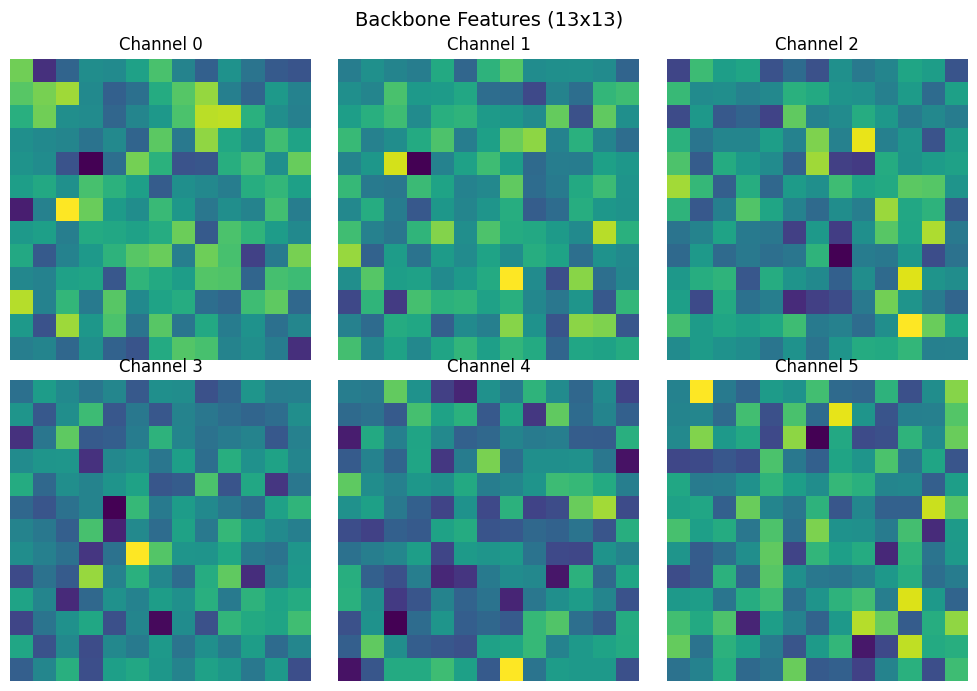

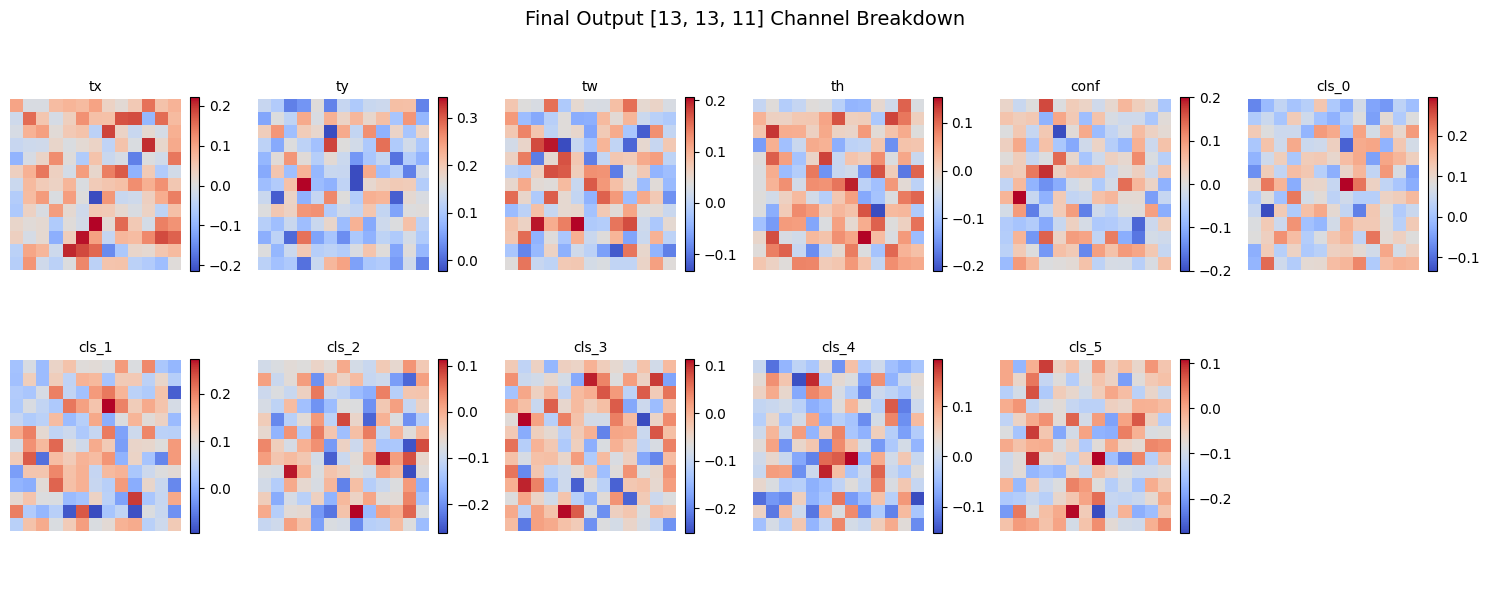

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 定义极简版 YOLOv3 检测头 (输出11通道)
# ==========================================
class TinyYOLOv3Head(nn.Module):
    """
    模拟 YOLOv3 的 13x13 检测头
    假设: B=1 (每个格子1个anchor), C=6 (6个类别)
    输出通道 = B * (5 + C) = 1 * (5 + 6) = 11
    """
    def __init__(self, in_channels=256, num_classes=6):
        super().__init__()
        # 几个卷积层用于提取特征并调整通道数
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels, 128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1, inplace=True),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1, inplace=True),
        )
        
        # 最终预测层: 输出11个通道 (4坐标 + 1置信度 + 6类别)
        self.prediction_layer = nn.Conv2d(256, 11, kernel_size=1)

    def forward(self, x):
        x = self.feature_extractor(x)
        output = self.prediction_layer(x)
        return output

# ==========================================
# 2. 实例化并验证维度变化
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TinyYOLOv3Head(num_classes=6).to(device)
model.eval() # 切换到评估模式(固定BN层)

# 模拟输入: Batch=1, Channels=3, H=416, W=416
input_img = torch.randn(1, 3, 416, 416).to(device)

# ⚠️ 注意: 实际YOLOv3中, 416->13是经过Darknet-53 backbone下采样32倍得到的
# 这里为了演示Head部分, 我们直接用插值模拟backbone的输出(13x13x256)
backbone_output = nn.functional.interpolate(input_img, size=(13, 13), mode='bilinear', align_corners=False)
# 将通道数从3变为256 (模拟backbone的特征提取)
dummy_backbone_out = torch.randn(1, 256, 13, 13).to(device) 

print(f"🖼️  原始输入图像形状: {tuple(input_img.shape)}")      # [1, 3, 416, 416]
print(f"🔽 Backbone输出形状: {tuple(dummy_backbone_out.shape)}") # [1, 256, 13, 13]

with torch.no_grad():
    final_output = model(dummy_backbone_out)

print(f"🎯 检测头输出形状: {tuple(final_output.shape)}")        # [1, 11, 13, 13]
print("-" * 40)
print("💡 维度解析:")
print(f"   - 13x13: 对应原图 416/32 = 13 个网格")
print(f"   - 11通道: 4(xywh) + 1(conf) + 6(classes)")

# ==========================================
# 3. 可视化特征图 (让抽象的Tensor变直观)
# ==========================================
def visualize_feature_maps(tensor, title="Feature Maps"):
    """取第一个batch的前几个通道进行可视化"""
    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    tensor_np = tensor[0].cpu().numpy() # 去掉batch维度 -> [11, 13, 13]
    
    for i, ax in enumerate(axes.flat):
        if i < tensor_np.shape[0]:
            ax.imshow(tensor_np[i], cmap='viridis')
            ax.set_title(f"Channel {i}")
            ax.axis('off')
        else:
            ax.axis('off')
            
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# 可视化 backbone 输出的特征 (256通道取前6个)
visualize_feature_maps(dummy_backbone_out[:, :6, :, :], "Backbone Features (13x13)")

# 可视化 最终输出的11个通道 (xywh + conf + classes)
channel_names = ['tx', 'ty', 'tw', 'th', 'conf', 'cls_0', 'cls_1', 'cls_2', 'cls_3', 'cls_4', 'cls_5']
fig, axes = plt.subplots(2, 6, figsize=(15, 6))
output_np = final_output[0].cpu().numpy()

for i, ax in enumerate(axes.flat):
    if i < 11:
        im = ax.imshow(output_np[i], cmap='coolwarm')
        ax.set_title(channel_names[i], fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)
    else:
        ax.axis('off')

plt.suptitle("Final Output [13, 13, 11] Channel Breakdown", fontsize=14)
plt.tight_layout()
plt.show()

                    Darknet-53 网络结构
层名                   输入通道       输出通道       输出尺寸            说明
----------------------------------------------------------------------
Input                3          3          416×416         原始输入图像
Stage0 Conv          3          32         416×416         3×3 Conv, stride=1
Stage1 Conv          32         64         208×208         3×3 Conv, stride=2 (下采样)
Stage1 Res×1         64         64         208×208         1个残差块
Stage2 Conv          64         128        104×104         3×3 Conv, stride=2 (下采样)
Stage2 Res×2         128        128        104×104         2个残差块
Stage3 Conv          128        256        52×52           3×3 Conv, stride=2 (下采样)
Stage3 Res×8         256        256        52×52           8个残差块  ← 🎯 检测尺度1
Stage4 Conv          256        512        26×26           3×3 Conv, stride=2 (下采样)
Stage4 Res×8         512        512        26×26           8个残差块  ← 🎯 检测尺度2
Stage5 Conv          512        1024       13×13           3×3 Conv, 

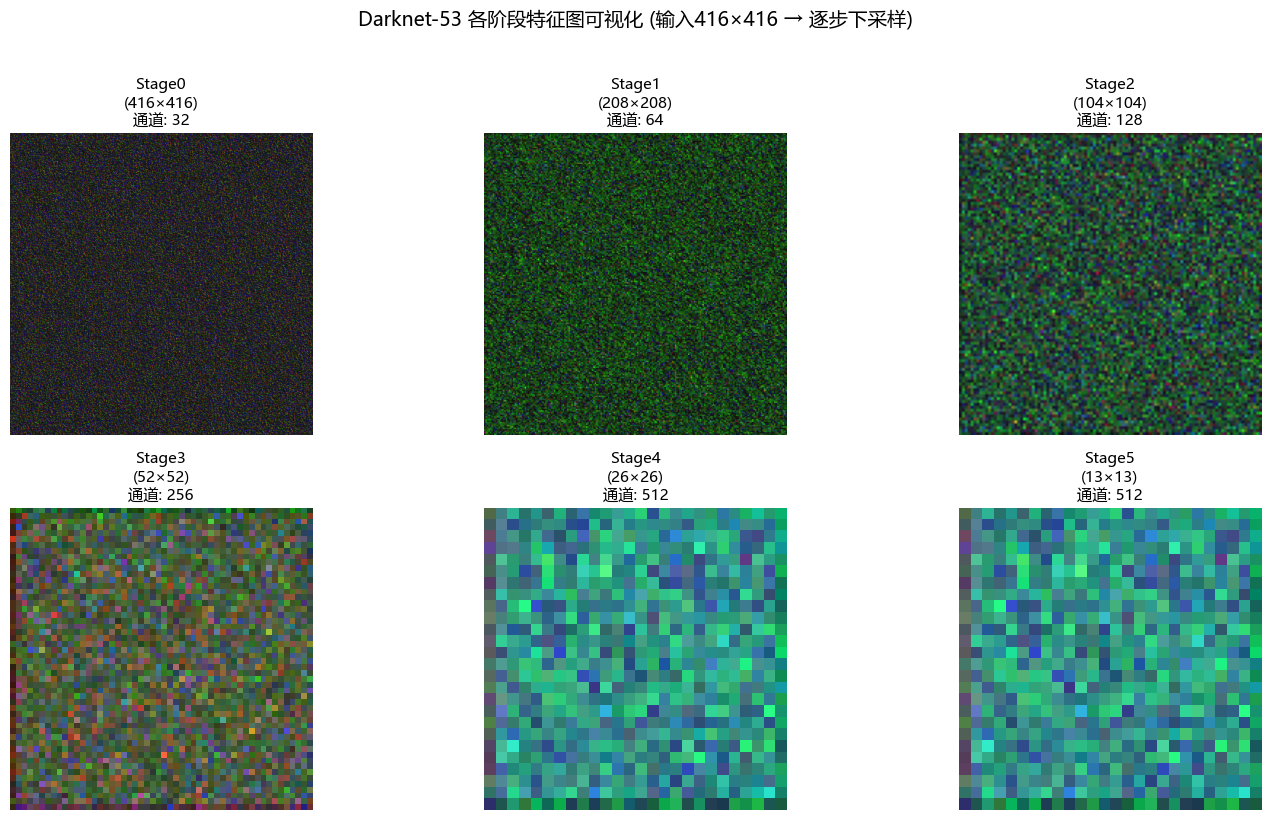


📊 Darknet-53 参数量统计:
   总参数量:     41.61M
   可训练参数:   41.61M
   理论计算量:   ~18.3 GFLOPs (在416×416输入下)

         残差块 (Residual Block) 内部结构

     输入 (channels=256)
          │
          ▼
     ┌─────────────┐
     │ Conv 1×1     │  ← 先降维 (256 → 128)
     │ BN + LeakyReLU│
     └──────┬──────┘
            │
            ▼
     ┌─────────────┐
     │ Conv 3×3     │  ← 再升维 (128 → 256)
     │ BN + LeakyReLU│
     └──────┬──────┘
            │
            ▼
         ┌─────┐
         │  +  │ ← ← ← ← ← 残差连接 (恒等映射)
         └──┬──┘
            │
     输出 (channels=256)

💡 这种 bottleneck 设计: 1×1降维 → 3×3特征提取 → 残差相加
   相比直接两层3×3, 计算量更小, 且能更好地融合跨通道信息


In [2]:
# ==========================================
# Darknet-53 网络结构演示
# YOLOv3 使用的骨干网络 (Backbone)
# 论文: YOLOv3: An Incremental Improvement
# ==========================================

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.font_manager as fm

# ==========================================
# 修复中文字体显示问题
# ==========================================
# Windows 系统优先使用微软雅黑
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# ------------------------------------------------------------
# 1. 基础组件: Conv + BN + LeakyReLU (Darknet的标配)
# ------------------------------------------------------------
class DarknetConvBlock(nn.Module):
    """Darknet风格的卷积块: Conv2d + BatchNorm + LeakyReLU"""
    def __init__(self, in_ch, out_ch, kernel_size, stride=1):
        super().__init__()
        padding = kernel_size // 2  # 保持空间尺寸
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size, stride, padding, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.1, inplace=True),
        )
    
    def forward(self, x):
        return self.conv(x)


# ------------------------------------------------------------
# 2. 残差块 (Residual Block) —— Darknet-53 的核心
# ------------------------------------------------------------
class DarknetResBlock(nn.Module):
    """
    Darknet 残差块: 1x1降维 → 3x3升维 + 残差连接
    结构: Conv1x1(↓通道) → Conv3x3(↑通道) → + 残差
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        hidden_ch = out_ch // 2  # 1x1 先压缩到一半
        self.block = nn.Sequential(
            DarknetConvBlock(in_ch, hidden_ch, kernel_size=1),   # 1x1 降维
            DarknetConvBlock(hidden_ch, out_ch, kernel_size=3),  # 3x3 升维
        )
    
    def forward(self, x):
        return x + self.block(x)  # 残差连接


# ------------------------------------------------------------
# 3. 完整 Darknet-53 网络
# ------------------------------------------------------------
class Darknet53(nn.Module):
    """
    Darknet-53 结构 (共 53 层卷积层)
    
    整体流程:
    输入(3, H, W)
      → Conv 3x3, stride=1  (下采样用stride=2的卷积代替池化)
      → 1x Residual Block × 1
      → 2x Residual Block × 2
      → 8x Residual Block × 8
      → 8x Residual Block × 8
      → 4x Residual Block × 4
      → AvgPool + FC (分类用)
    
    三个尺度的特征图输出给YOLOv3检测头:
      - 下采样 8倍  → 大尺度 (检测小目标)
      - 下采样 16倍 → 中尺度
      - 下采样 32倍 → 小尺度 (检测大目标)
    """
    def __init__(self, num_classes=1000):
        super().__init__()
        
        # ---------- Stage 0: 初始卷积 ----------
        # 输入 (3, H, W) → (32, H/2, W/2)
        self.stage0 = DarknetConvBlock(3, 32, kernel_size=3, stride=1)
        
        # ---------- Stage 1: 下采样 + 1个残差块 ----------
        # (32, H/2, W/2) → (64, H/4, W/4)
        self.stage1_conv = DarknetConvBlock(32, 64, kernel_size=3, stride=2)
        self.stage1_res = nn.Sequential(*[DarknetResBlock(64, 64) for _ in range(1)])
        
        # ---------- Stage 2: 下采样 + 2个残差块 ----------
        # (64, H/4, W/4) → (128, H/8, W/8)   ← YOLO检测尺度1 (下采样8倍)
        self.stage2_conv = DarknetConvBlock(64, 128, kernel_size=3, stride=2)
        self.stage2_res = nn.Sequential(*[DarknetResBlock(128, 128) for _ in range(2)])
        
        # ---------- Stage 3: 下采样 + 8个残差块 ----------
        # (128, H/8, W/8) → (256, H/16, W/16)  ← YOLO检测尺度2 (下采样16倍)
        self.stage3_conv = DarknetConvBlock(128, 256, kernel_size=3, stride=2)
        self.stage3_res = nn.Sequential(*[DarknetResBlock(256, 256) for _ in range(8)])
        
        # ---------- Stage 4: 下采样 + 8个残差块 ----------
        # (256, H/16, W/16) → (512, H/32, W/32)  ← YOLO检测尺度3 (下采样32倍)
        self.stage4_conv = DarknetConvBlock(256, 512, kernel_size=3, stride=2)
        self.stage4_res = nn.Sequential(*[DarknetResBlock(512, 512) for _ in range(8)])
        
        # ---------- Stage 5: 下采样 + 4个残差块 ----------
        # (512, H/32, W/32) → (1024, H/64, W/64)
        self.stage5_conv = DarknetConvBlock(512, 1024, kernel_size=3, stride=2)
        self.stage5_res = nn.Sequential(*[DarknetResBlock(1024, 1024) for _ in range(4)])
        
        # ---------- 分类头 (ImageNet预训练用) ----------
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(1024, num_classes)
        
        # 记录各层输出形状 (用于forward时的信息收集)
        self.intermediate_shapes = {}
    
    def forward(self, x, return_features=False):
        """
        Args:
            x: 输入图像 (B, 3, H, W)
            return_features: 若为True, 返回三个尺度的特征图供YOLO检测头使用
        """
        # Stage 0
        x = self.stage0(x)
        
        # Stage 1 (下采样2倍)
        x = self.stage1_conv(x)
        x = self.stage1_res(x)
        
        # Stage 2 (下采样4倍 → 总下采样8倍)
        x = self.stage2_conv(x)
        x = self.stage2_res(x)
        feat_8x = x  # ← 尺度1: 下采样8倍 (检测小目标)
        
        # Stage 3 (下采样8倍 → 总下采样16倍)
        x = self.stage3_conv(x)
        x = self.stage3_res(x)
        feat_16x = x  # ← 尺度2: 下采样16倍 (检测中目标)
        
        # Stage 4 (下采样16倍 → 总下采样32倍)
        x = self.stage4_conv(x)
        x = self.stage4_res(x)
        feat_32x = x  # ← 尺度3: 下采样32倍 (检测大目标)
        
        # Stage 5
        x = self.stage5_conv(x)
        x = self.stage5_res(x)
        
        # 分类头
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        if return_features:
            return x, (feat_8x, feat_16x, feat_32x)
        return x


# ============================================================
# 4. 可视化网络结构与特征图变化
# ============================================================
def print_network_architecture():
    """以文本形式打印 Darknet-53 的结构"""
    print("=" * 70)
    print("                    Darknet-53 网络结构")
    print("=" * 70)
    print(f"{'层名':<20} {'输入通道':<10} {'输出通道':<10} {'输出尺寸':<15} {'说明'}")
    print("-" * 70)
    
    # 模拟一个结构表
    layers = [
        ("Input", 3, 3, "416×416", "原始输入图像"),
        ("Stage0 Conv", 3, 32, "416×416", "3×3 Conv, stride=1"),
        ("Stage1 Conv", 32, 64, "208×208", "3×3 Conv, stride=2 (下采样)"),
        ("Stage1 Res×1", 64, 64, "208×208", "1个残差块"),
        ("Stage2 Conv", 64, 128, "104×104", "3×3 Conv, stride=2 (下采样)"),
        ("Stage2 Res×2", 128, 128, "104×104", "2个残差块"),
        ("Stage3 Conv", 128, 256, "52×52", "3×3 Conv, stride=2 (下采样)"),
        ("Stage3 Res×8", 256, 256, "52×52", "8个残差块  ← 🎯 检测尺度1"),
        ("Stage4 Conv", 256, 512, "26×26", "3×3 Conv, stride=2 (下采样)"),
        ("Stage4 Res×8", 512, 512, "26×26", "8个残差块  ← 🎯 检测尺度2"),
        ("Stage5 Conv", 512, 1024, "13×13", "3×3 Conv, stride=2 (下采样)"),
        ("Stage5 Res×4", 1024, 1024, "13×13", "4个残差块  ← 🎯 检测尺度3"),
    ]
    
    for name, in_ch, out_ch, size, note in layers:
        in_str = str(in_ch) if in_ch else "-"
        out_str = str(out_ch) if out_ch else "-"
        print(f"{name:<20} {in_str:<10} {out_str:<10} {size:<15} {note}")
    
    print("-" * 70)
    print(f"{'总卷积层数':>55} {53}")
    print("=" * 70)


# ============================================================
# 5. 实例化并测试
# ============================================================
print_network_architecture()
print("\n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Darknet53(num_classes=1000).to(device)
model.eval()

# 模拟输入: YOLOv3 标准输入 416×416
batch_size = 1
input_img = torch.randn(batch_size, 3, 416, 416).to(device)

print(f"📥 输入形状: {tuple(input_img.shape)}")

with torch.no_grad():
    logits, (feat_8x, feat_16x, feat_32x) = model(input_img, return_features=True)

print(f"📤 分类输出形状: {tuple(logits.shape)}  (1000类 ImageNet)")
print(f"\n🔍 三个检测尺度的特征图:")
print(f"   尺度1 (下采样8倍):  {tuple(feat_8x.shape)}   → 用于检测小目标")
print(f"   尺度2 (下采样16倍): {tuple(feat_16x.shape)}  → 用于检测中目标")
print(f"   尺度3 (下采样32倍): {tuple(feat_32x.shape)}  → 用于检测大目标")

# ============================================================
# 6. 可视化: 各stage特征图
# ============================================================
def visualize_stages(model, input_tensor):
    """前向传播过程中可视化各stage的输出"""
    x = input_tensor
    activations = {}
    
    # 手动前向收集各层输出
    x = model.stage0(x)
    activations['stage0'] = x
    
    x = model.stage1_conv(x); x = model.stage1_res(x)
    activations['stage1'] = x
    
    x = model.stage2_conv(x); x = model.stage2_res(x)
    activations['stage2'] = x  # 8x
    
    x = model.stage3_conv(x); x = model.stage3_res(x)
    activations['stage3'] = x  # 16x
    
    x = model.stage4_conv(x); x = model.stage4_res(x)
    activations['stage4'] = x  # 32x
    
    return activations

with torch.no_grad():
    acts = visualize_stages(model, input_img)

# 绘制各stage输出形状和特征图
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
stage_names = ['Stage0\n(416×416)', 'Stage1\n(208×208)', 'Stage2\n(104×104)', 
               'Stage3\n(52×52)', 'Stage4\n(26×26)', 'Stage5\n(13×13)']
stage_keys = ['stage0', 'stage1', 'stage2', 'stage3', 'stage4', 'stage4']  # stage5用了stage4的输出

for idx, (name, key) in enumerate(zip(stage_names, stage_keys)):
    ax = axes.flat[idx]
    feat = acts[key] if key in acts else acts['stage4']  # stage5没有单独存, 用stage4代替
    # 取前3个通道拼接成伪RGB图
    feat_np = feat[0, :3].cpu().numpy()
    # 归一化到[0,1]显示
    feat_min, feat_max = feat_np.min(), feat_np.max()
    feat_np = (feat_np - feat_min) / (feat_max - feat_min + 1e-8)
    # 转置为 (H, W, C)
    feat_np = np.transpose(feat_np, (1, 2, 0))
    
    ax.imshow(feat_np)
    ax.set_title(f"{name}\n通道: {feat.shape[1]}", fontsize=11)
    ax.axis('off')

plt.suptitle("Darknet-53 各阶段特征图可视化 (输入416×416 → 逐步下采样)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# 7. 统计信息
# ============================================================
def count_parameters(model):
    """统计模型参数量"""
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)
print(f"\n📊 Darknet-53 参数量统计:")
print(f"   总参数量:     {total_params/1e6:.2f}M")
print(f"   可训练参数:   {trainable_params/1e6:.2f}M")
print(f"   理论计算量:   ~18.3 GFLOPs (在416×416输入下)")

# ============================================================
# 8. 残差块内部结构详解
# ============================================================
print("\n" + "=" * 70)
print("         残差块 (Residual Block) 内部结构")
print("=" * 70)
print("""
     输入 (channels=256)
          │
          ▼
     ┌─────────────┐
     │ Conv 1×1     │  ← 先降维 (256 → 128)
     │ BN + LeakyReLU│
     └──────┬──────┘
            │
            ▼
     ┌─────────────┐
     │ Conv 3×3     │  ← 再升维 (128 → 256)
     │ BN + LeakyReLU│
     └──────┬──────┘
            │
            ▼
         ┌─────┐
         │  +  │ ← ← ← ← ← 残差连接 (恒等映射)
         └──┬──┘
            │
     输出 (channels=256)
""")
print("💡 这种 bottleneck 设计: 1×1降维 → 3×3特征提取 → 残差相加")
print("   相比直接两层3×3, 计算量更小, 且能更好地融合跨通道信息")

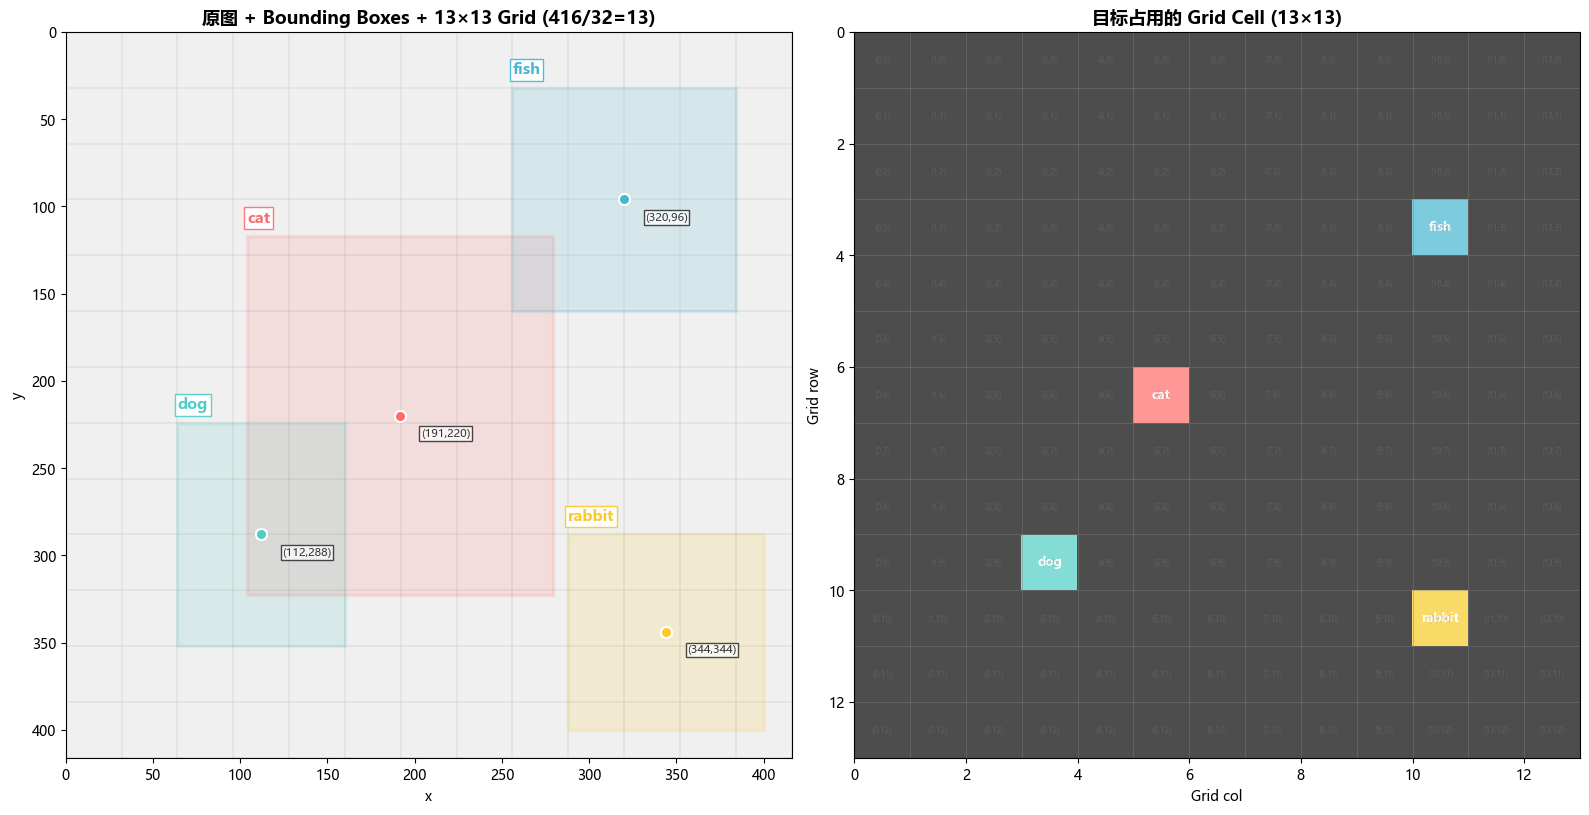

          各目标对应的 Grid Cell 位置
目标         中心点 (cx,cy)          Grid (col,row)     类别ID    
------------------------------------------------------------
cat        (  191.5,   220.0)        (5, 6)            0
dog        (  112.0,   288.0)        (3, 9)            1
fish       (  320.0,    96.0)        (10, 3)            2
rabbit     (  344.0,   344.0)        (10, 10)            3

💡 说明: 416/32=13, 每个Grid Cell尺寸为 32×32 像素
   目标中心点落在哪个格子, 就由哪个格子负责检测该目标


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# ==========================================
# 修复中文字体显示
# ==========================================
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 定义4个目标 ----------
# 格式: (xmin, ymin, xmax, ymax)
targets = {
    'cat':   (104, 117, 279, 323),
    'dog':   (64,  224, 160, 352),
    'fish':  (256, 32,  384, 160),
    'rabbit':(288, 288, 400, 400),
}

# 给每个目标分配颜色和类别ID
class_names = ['cat', 'dog', 'fish', 'rabbit', 'bird', 'snake']  # 6个类别
class_colors = ['#ff6b6b', '#4ecdc4', '#45b7d1', '#f9ca24', '#a29bfe', '#fd79a8']
target_class_ids = {
    'cat':   0,
    'dog':   1,
    'fish':  2,
    'rabbit':3,
}

# ---------- 创建画布 ----------
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ---- 左图: 原始图 + 边框 + 13×13 Grid ----
ax1 = axes[0]
ax1.set_xlim(0, 416)
ax1.set_ylim(416, 0)
ax1.set_aspect('equal')
ax1.set_title('原图 + Bounding Boxes + 13×13 Grid (416/32=13)', fontsize=13, fontweight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# 绘制灰色背景
ax1.add_patch(patches.Rectangle((0, 0), 416, 416, facecolor='#f0f0f0', edgecolor='none'))

# 绘制13×13 Grid
grid_size = 416 // 13  # = 32
for i in range(14):  # 14条线 (13个格子)
    # 竖线
    ax1.axvline(i * grid_size, color='gray', linewidth=0.3, alpha=0.5)
    # 横线
    ax1.axhline(i * grid_size, color='gray', linewidth=0.3, alpha=0.5)

# 绘制每个目标的 bounding box
for name, (x1, y1, x2, y2) in targets.items():
    cid = target_class_ids[name]
    color = class_colors[cid]
    w = x2 - x1
    h = y2 - y1
    
    # 画矩形框
    rect = patches.Rectangle((x1, y1), w, h, linewidth=2.5,
                             edgecolor=color, facecolor=color, alpha=0.15)
    ax1.add_patch(rect)
    
    # 标注中心点
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    ax1.plot(cx, cy, 'o', color=color, markersize=8, markeredgecolor='white', markeredgewidth=1.5)
    
    # 标注类别和坐标
    ax1.text(x1, y1 - 8, f'{name}', fontsize=11, fontweight='bold',
             color=color, bbox=dict(facecolor='white', edgecolor=color, pad=2, alpha=0.9))
    ax1.text(cx + 12, cy + 12, f'({int(cx)},{int(cy)})', fontsize=8,
             color='#333', bbox=dict(facecolor='white', pad=1, alpha=0.7))

# ---- 右图: Grid 热力图 (显示哪些格子被占用了) ----
ax2 = axes[1]
ax2.set_xlim(0, 13)
ax2.set_ylim(13, 0)
ax2.set_aspect('equal')
ax2.set_title('目标占用的 Grid Cell (13×13)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Grid col')
ax2.set_ylabel('Grid row')

# 创建Grid占用矩阵
grid_map = np.zeros((13, 13, 3), dtype=np.float32)

# 标记每个目标占用的cell
for name, (x1, y1, x2, y2) in targets.items():
    cid = target_class_ids[name]
    color_rgb = [int(class_colors[cid][i:i+2], 16)/255 for i in (1, 3, 5)]
    
    cx_norm = (x1 + x2) / 2  # 中心点x (0~416)
    cy_norm = (y1 + y2) / 2  # 中心点y (0~416)
    
    col = int(cx_norm // grid_size)  # 所在Grid列
    row = int(cy_norm // grid_size)  # 所在Grid行
    
    # 给占用格子上色
    grid_map[row, col] = color_rgb
    
    # 标注类别
    ax2.text(col + 0.5, row + 0.5, name, fontsize=9, fontweight='bold',
             ha='center', va='center', color='white',
             bbox=dict(facecolor='none', edgecolor='none'))

# 显示Grid热力图
ax2.imshow(grid_map, extent=(0, 13, 13, 0), alpha=0.7)

# 绘制Grid线
for i in range(14):
    ax2.axvline(i, color='gray', linewidth=0.5, alpha=0.6)
    ax2.axhline(i, color='gray', linewidth=0.5, alpha=0.6)

# 在格子中写上坐标编号
for row in range(13):
    for col in range(13):
        ax2.text(col + 0.5, row + 0.5, f'({col},{row})', fontsize=5.5,
                 ha='center', va='center', color='gray', alpha=0.35)

plt.tight_layout()
plt.show()

# ---------- 输出每个目标的Grid位置 ----------
print("=" * 60)
print("          各目标对应的 Grid Cell 位置")
print("=" * 60)
print(f"{'目标':<10} {'中心点 (cx,cy)':<20} {'Grid (col,row)':<18} {'类别ID':<8}")
print("-" * 60)
for name, (x1, y1, x2, y2) in targets.items():
    cx = (x1 + x2) / 2
    cy = (y1 + y2) / 2
    col = int(cx // grid_size)
    row = int(cy // grid_size)
    cid = target_class_ids[name]
    print(f"{name:<10} ({cx:7.1f}, {cy:7.1f})        ({col}, {row})            {cid}")
print("=" * 60)
print(f"\n💡 说明: 416/32=13, 每个Grid Cell尺寸为 32×32 像素")
print(f"   目标中心点落在哪个格子, 就由哪个格子负责检测该目标")

Step 1: (x1,y1,x2,y2) → (cx,cy,w,h) 归一化坐标
  cat       (104,117,279,323)  →  cx=0.4603, cy=0.5288, w=0.4207, h=0.4952  (cls=0)
  dog       ( 64,224,160,352)  →  cx=0.2692, cy=0.6923, w=0.2308, h=0.3077  (cls=1)
  fish      (256, 32,384,160)  →  cx=0.7692, cy=0.2308, w=0.3077, h=0.3077  (cls=2)
  rabbit    (288,288,400,400)  →  cx=0.8269, cy=0.8269, w=0.2692, h=0.2692  (cls=3)

Step 2: 确定每个目标中心点所在的 Grid Cell (col, row)
  cat       中心( 191.5, 220.0)  →  Grid[6,5]  偏移(0.9844,0.8750)  cls=0
  dog       中心( 112.0, 288.0)  →  Grid[9,3]  偏移(0.5000,0.0000)  cls=1
  fish      中心( 320.0,  96.0)  →  Grid[3,10]  偏移(0.0000,0.0000)  cls=2
  rabbit    中心( 344.0, 344.0)  →  Grid[10,10]  偏移(0.7500,0.7500)  cls=3

Step 3: 构建 Ground Truth 张量 (13, 13, 10)
  cat      → Grid[6,5]  |  cx=0.9844  cy=0.8750  w=0.4207  h=0.4952  conf=1  cls0=1
  dog      → Grid[9,3]  |  cx=0.5000  cy=0.0000  w=0.2308  h=0.3077  conf=1  cls1=1
  fish     → Grid[3,10]  |  cx=0.0000  cy=0.0000  w=0.3077  h=0.3077  conf=1  cls2=1
  

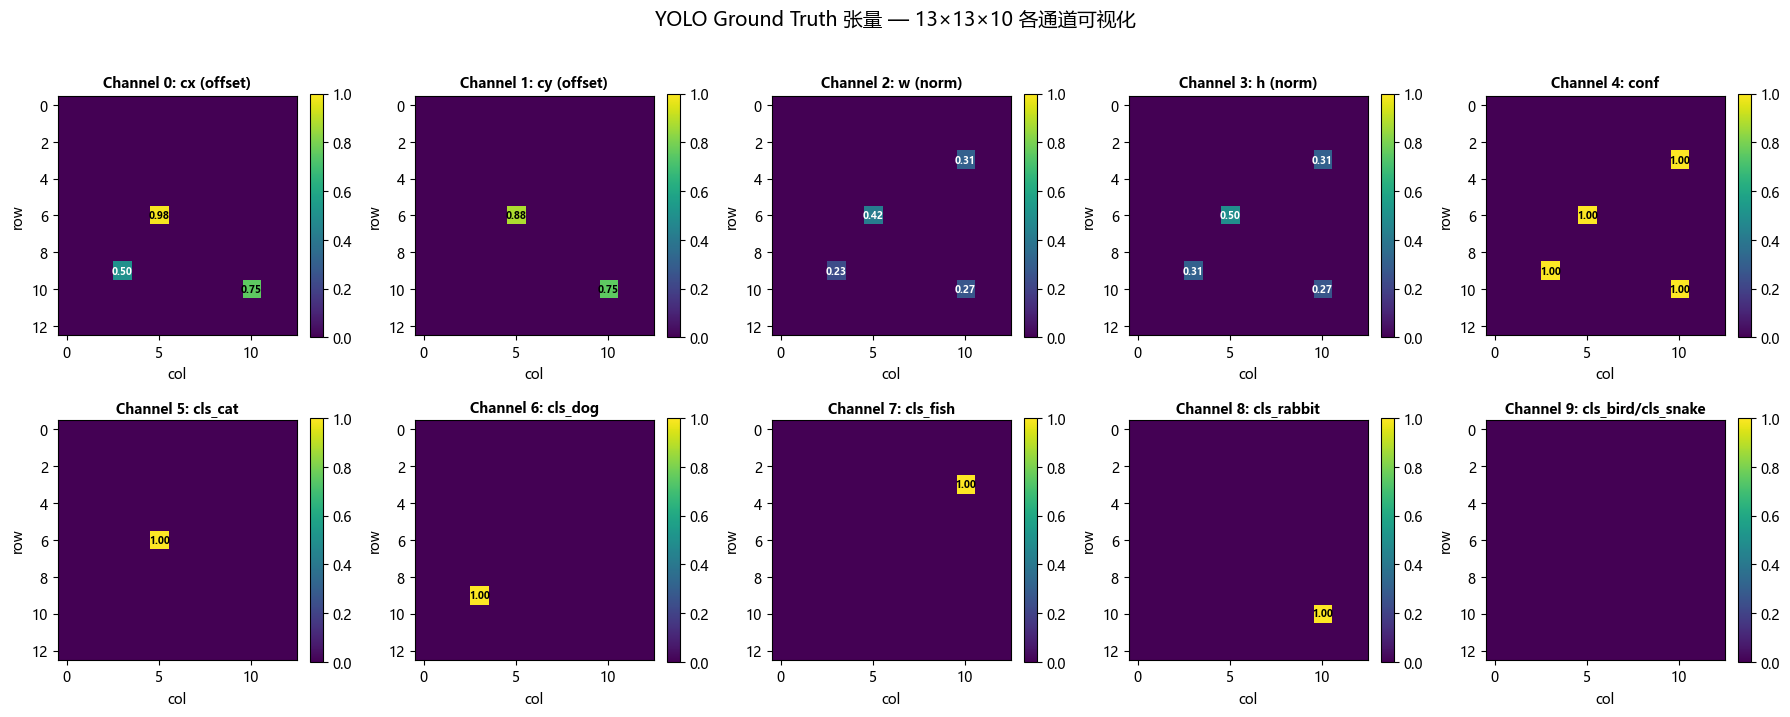

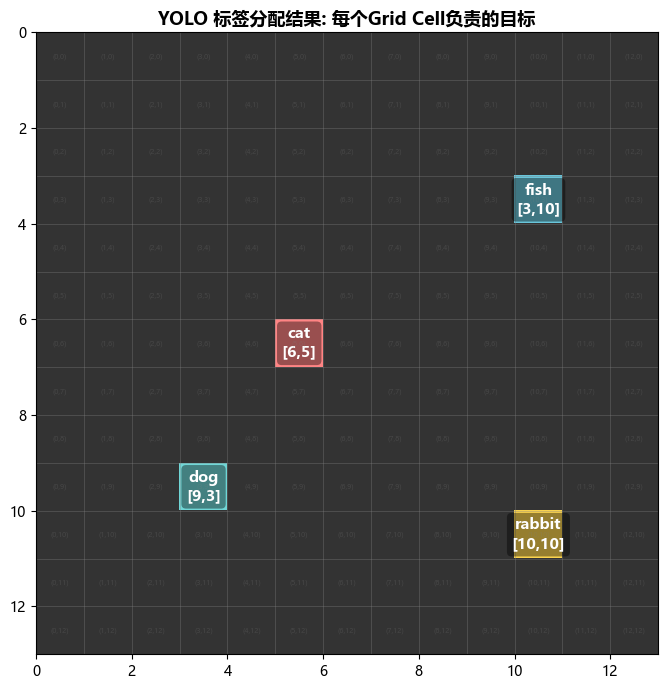


Step 5: 验证 — GT 张量与模型输出维度对照

  ┌─────────────────────────────────────────────────────┐
  │                                                     │
  │  模型输出:  (B, 10, 13, 13)                          │
  │                │   │   └── Grid 行数                │
  │                │   └────── Grid 列数                │
  │                └───────── 10通道: 4(cx,cy,w,h)      │
  │                                     + 6(cls0~cls5)  │
  │                                                     │
  │  GT张量:    (13, 13, 10)                            │
  │                                                     │
  │  Loss计算时: 取出有目标的格子 (conf=1) 算回归loss     │
  │              所有格子算分类loss (有目标→1, 无→0)     │
  └─────────────────────────────────────────────────────┘

✅ Ground Truth 编码完成!
   GT张量形状: (13, 13, 10)
   其中非零格子: 4 / 169
   每个有目标的格子包含: [cx, cy, w, h, conf=1, cls_onehot]


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ==========================================
# 修复中文字体显示
# ==========================================
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ---------- 参数设置 ----------
IMG_SIZE = 416
GRID_SIZE = 13          # 13×13 Grid
CELL_SIZE = IMG_SIZE // GRID_SIZE  # 32

NUM_CLASSES = 6
class_names = ['cat', 'dog', 'fish', 'rabbit', 'bird', 'snake']

# ---------- 原始标注数据 (x1,y1,x2,y2) ----------
targets_raw = {
    'cat':   (104, 117, 279, 323, 0),   # (x1,y1,x2,y2, class_id)
    'dog':   (64,  224, 160, 352, 1),
    'fish':  (256, 32,  384, 160, 2),
    'rabbit':(288, 288, 400, 400, 3),
}

# ============================================================
# Step 1: 将 (x1,y1,x2,y2) 转换为 (cx,cy,w,h)
# 并进行归一化 (除以图片尺寸 416)
# ============================================================
print("=" * 70)
print("Step 1: (x1,y1,x2,y2) → (cx,cy,w,h) 归一化坐标")
print("=" * 70)

boxes_normalized = []
for name, (x1, y1, x2, y2, cid) in targets_raw.items():
    # 计算中心点和宽高
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0
    w  = x2 - x1
    h  = y2 - y1
    
    # 归一化到 [0, 1]
    cx_norm = cx / IMG_SIZE
    cy_norm = cy / IMG_SIZE
    w_norm  = w  / IMG_SIZE
    h_norm  = h  / IMG_SIZE
    
    boxes_normalized.append((name, cx_norm, cy_norm, w_norm, h_norm, cid))
    
    print(f"  {name:<8}  ({x1:3d},{y1:3d},{x2:3d},{y2:3d})  →  "
          f"cx={cx_norm:.4f}, cy={cy_norm:.4f}, w={w_norm:.4f}, h={h_norm:.4f}  (cls={cid})")

# ============================================================
# Step 2: 确定每个目标落在哪个 Grid Cell
# ============================================================
print("\n" + "=" * 70)
print("Step 2: 确定每个目标中心点所在的 Grid Cell (col, row)")
print("=" * 70)

grid_assignments = []
for name, cx_norm, cy_norm, w_norm, h_norm, cid in boxes_normalized:
    # 将归一化坐标映射回像素坐标，再确定Grid位置
    cx_pixel = cx_norm * IMG_SIZE
    cy_pixel = cy_norm * IMG_SIZE
    col = int(cx_pixel // CELL_SIZE)   # 所在列
    row = int(cy_pixel // CELL_SIZE)   # 所在行
    
    # 计算相对于所在Cell的偏移 (用于YOLO的相对坐标)
    cell_cx = (cx_pixel - col * CELL_SIZE) / CELL_SIZE  # 0~1
    cell_cy = (cy_pixel - row * CELL_SIZE) / CELL_SIZE  # 0~1
    
    grid_assignments.append((name, row, col, cell_cx, cell_cy, cid))
    
    print(f"  {name:<8}  中心({cx_pixel:6.1f},{cy_pixel:6.1f})  →  "
          f"Grid[{row},{col}]  偏移({cell_cx:.4f},{cell_cy:.4f})  cls={cid}")

# ============================================================
# Step 3: 构建 Ground Truth 张量 (13, 13, 10)
# ============================================================
print("\n" + "=" * 70)
print("Step 3: 构建 Ground Truth 张量 (13, 13, 10)")
print("=" * 70)

# 初始化GT张量: 全部为0
gt_tensor = np.zeros((GRID_SIZE, GRID_SIZE, 10), dtype=np.float32)

# channel索引:
#   0: cx    (相对当前cell的偏移)
#   1: cy    (相对当前cell的偏移)
#   2: w     (归一化到图片尺寸)
#   3: h     (归一化到图片尺寸)
#   4: conf  (有无目标: 0或1)
#   5~9: cls0~cls5 (one-hot类别编码)

for name, row, col, cell_cx, cell_cy, cid in grid_assignments:
    # 找到对应的归一化宽高
    _, cx_norm, cy_norm, w_norm, h_norm, _ = [
        b for b in boxes_normalized if b[0] == name
    ][0]
    
    # 填充坐标 (相对当前cell的偏移)
    gt_tensor[row, col, 0] = cell_cx   # cx 相对offset
    gt_tensor[row, col, 1] = cell_cy   # cy 相对offset
    gt_tensor[row, col, 2] = w_norm    # 归一化宽
    gt_tensor[row, col, 3] = h_norm    # 归一化高
    gt_tensor[row, col, 4] = 1.0       # conf = 1 (有目标)
    gt_tensor[row, col, 5 + cid] = 1.0 # one-hot 类别
    
    print(f"  {name:<8} → Grid[{row},{col}]  |  "
          f"cx={cell_cx:.4f}  cy={cell_cy:.4f}  w={w_norm:.4f}  h={h_norm:.4f}  "
          f"conf=1  cls{chr(ord('0')+cid)}=1")

print(f"\n📐 GT张量形状: {gt_tensor.shape}  =  ({GRID_SIZE}, {GRID_SIZE}, 10)")
print(f"📊 非零元素数量: {np.count_nonzero(gt_tensor)}  (共 {GRID_SIZE*GRID_SIZE*10} 个元素)")
print(f"🎯 有目标的Grid Cell数: {np.count_nonzero(gt_tensor[:,:,4])}  (共 {GRID_SIZE*GRID_SIZE} 个格子)")

# ============================================================
# Step 4: 可视化 Ground Truth 张量的每个通道
# ============================================================
print("\n" + "=" * 70)
print("Step 4: 可视化 GT 张量的 10 个通道")
print("=" * 70)

channel_labels = ['cx (offset)', 'cy (offset)', 'w (norm)', 'h (norm)',
                  'conf', 'cls_cat', 'cls_dog', 'cls_fish', 'cls_rabbit', 'cls_bird/cls_snake']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, (ax, label) in enumerate(zip(axes.flat, channel_labels)):
    im = ax.imshow(gt_tensor[:, :, i], cmap='viridis', vmin=0, vmax=1)
    ax.set_title(f'Channel {i}: {label}', fontsize=10, fontweight='bold')
    ax.set_xlabel('col')
    ax.set_ylabel('row')
    
    # 标注有值的格子
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            val = gt_tensor[row, col, i]
            if val > 0:
                ax.text(col, row, f'{val:.2f}', fontsize=7, ha='center', va='center',
                        color='white' if val < 0.6 else 'black', fontweight='bold')
    
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('YOLO Ground Truth 张量 — 13×13×10 各通道可视化', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# Step 5: 绘制 Grid 热力图 — 哪个格子负责哪个目标
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
ax.set_xlim(0, 13)
ax.set_ylim(13, 0)
ax.set_aspect('equal')
ax.set_title('YOLO 标签分配结果: 每个Grid Cell负责的目标', fontsize=13, fontweight='bold')

# 背景网格
grid_viz = np.zeros((13, 13, 3), dtype=np.float32)
colors_map = {'cat': [1, 0.4, 0.4], 'dog': [0.3, 0.8, 0.8], 
              'fish': [0.27, 0.72, 0.82], 'rabbit': [0.98, 0.79, 0.14]}

for name, row, col, _, _, cid in grid_assignments:
    grid_viz[row, col] = colors_map[name]
    # 在格子里显示目标信息
    info = f"{name}\n[{row},{col}]"
    ax.text(col + 0.5, row + 0.5, info, fontsize=11, fontweight='bold',
            ha='center', va='center',
            color='white', bbox=dict(boxstyle='round,pad=0.3',
            facecolor='black', edgecolor='none', alpha=0.4))

ax.imshow(grid_viz, extent=(0, 13, 13, 0), alpha=0.8)

# Grid线
for i in range(14):
    ax.axvline(i, color='gray', linewidth=0.5, alpha=0.5)
    ax.axhline(i, color='gray', linewidth=0.5, alpha=0.5)

# 标注所有格子的坐标
for row in range(13):
    for col in range(13):
        ax.text(col + 0.5, row + 0.5, f'({col},{row})', fontsize=5,
                ha='center', va='center', color='gray', alpha=0.25)

plt.tight_layout()
plt.show()

# ============================================================
# Step 6: 验证 — 将GT张量与模型输出形状对应
# ============================================================
print("\n" + "=" * 70)
print("Step 5: 验证 — GT 张量与模型输出维度对照")
print("=" * 70)
print(f"""
  ┌─────────────────────────────────────────────────────┐
  │                                                     │
  │  模型输出:  (B, 10, 13, 13)                          │
  │                │   │   └── Grid 行数                │
  │                │   └────── Grid 列数                │
  │                └───────── 10通道: 4(cx,cy,w,h)      │
  │                                     + 6(cls0~cls5)  │
  │                                                     │
  │  GT张量:    (13, 13, 10)                            │
  │                                                     │
  │  Loss计算时: 取出有目标的格子 (conf=1) 算回归loss     │
  │              所有格子算分类loss (有目标→1, 无→0)     │
  └─────────────────────────────────────────────────────┘
""")

print("✅ Ground Truth 编码完成!")
print(f"   GT张量形状: {gt_tensor.shape}")
print(f"   其中非零格子: {np.count_nonzero(gt_tensor[:,:,4])} / {GRID_SIZE*GRID_SIZE}")
print(f"   每个有目标的格子包含: [cx, cy, w, h, conf=1, cls_onehot]")

# YOLOv3 原理完整梳理（从单目标→YOLOv3）

---

## 一、起点：单目标检测的问题

### 1.1 我们之前做的

```
输入 (3,300,300) → CNN特征提取 → Flatten → Linear(512,5) → (B,5)
                                                              ├── x1,y1,x2,y2 (框坐标)
                                                              └── conf (有无目标)
```

**特点**：整张图只输出 **1 个框**。

### 1.2 直接推广到多目标的困境

如果简单地把输出从 5 维变成 `(4 + N类)` 维：

```
尝试: n×5 → n×(4+5) = n×9
```

❌ **问题 1**：坐标归属无法判断 — 多个目标的框混在一起，不知道哪个坐标对应哪个目标  
❌ **问题 2**：one-hot 只能输出一个类 — 图片里有猫又有狗，一个 one-hot 向量无法同时表达

👉 **结论**：必须引入新的网络结构设计 —— **YOLO**

---

## 二、YOLO 的核心思想

> **YOLO = You Only Look Once**  
> 将目标检测视为 **回归问题**，一次前向推理直接输出所有目标的位置和类别

### 2.1 三个关键设计

```
┌───────────────────────────────────────────────────────────┐
│                                                           │
│   ① 划分 Grid              ② 每个格子负责一个目标        │
│   ┌──┬──┬──┬──┬──┐         ┌──┬──┬──┬──┬──┐             │
│   │  │  │  │  │  │         │  │  │  │  │  │             │
│   ├──┼──┼──┼──┼──┤         ├──┼──┼──┼──┼──┤             │
│   │  │  │● │  │  │         │  │  │猫│  │  │             │
│   ├──┼──┼──┼──┼──┤         ├──┼──┼──┼──┼──┤             │
│   │  │  │  │  │  │         │  │  │  │  │  │             │
│   ├──┼──┼──┼──┼──┤         ├──┼──┼──┼──┼──┤             │
│   │  │  │  │  │  │         │  │  │  │  │  │             │
│   └──┴──┴──┴──┴──┘         └──┴──┴──┴──┴──┘             │
│                                                           │
│   ③ 每个格子预测固定长度的向量                             │
│   [conf, cx, cy, w, h, cls0, cls1, cls2, ...]            │
│                                                           │
└───────────────────────────────────────────────────────────┘
```

**① 划分 Grid**：将图片分成 $S \times S$ 个网格（YOLOv3 默认 $S=13$）  
**② 目标分配**：目标中心落在哪个格子，就由那个格子负责检测  
**③ 通道编码**：每个格子用一个固定长度的向量表示预测信息

### 2.2 坐标系的改变

```
原来的坐标: (x1, y1, x2, y2)
            ┌─────────────┐
            │             │
            │    (x2,y2)  │
            │(x1,y1)      │
            └─────────────┘
    问题: x1,y1 和 x2,y2 耦合在一起, 网络难拟合

YOLO的坐标: (cx, cy, w, h)
                  ┌─────┐
                  │  ↑  │
                  │  h  │
                  └──┼──┘
                  ←w→←→
                 (cx,cy)
    优点: 中心点和宽高解耦, 分别预测, 降低拟合难度
```

---

## 三、从原图到特征图：下采样

### 3.1 416 → 13 的魔法

```
原图: 416 × 416 × 3
   │
   │  经过 Darknet-53 backbone (下采样 32 倍)
   ▼
特征图: 13 × 13 × 通道数
```

**为什么是 13？** $416 \div 32 = 13$，每个 Grid Cell 对应原图 $32 \times 32$ 像素的区域。

### 3.2 卷积位置相关性

```
原图左上角的猫 ──→ 经过卷积下采样 ──→ 特征图左上角仍然有猫
                                        
  416×416                   13×13
  ┌──────┐                 ┌──────┐
  │🐱    │   下采样32倍     │🐱    │
  │      │   ────────→     │      │
  │    🐶│                 │    🐶│
  └──────┘                 └──────┘
```

**关键**：卷积不破坏空间位置关系，原图中的位置关系在特征图中保持。

### 3.3 三个检测尺度（YOLOv3 的重要改进）

YOLOv3 不像 YOLOv1/v2 只用单尺度，而是用了 **3 个尺度** 来检测不同大小的目标：

```
              Darknet-53
   416×416        │
      │           │
      ▼           ▼
   ┌─────────────────────────────────┐
   │                                 │
   │    Stage2: 104×104×128          │
   │      │  下采样8倍               │
   │      ▼                          │
   │   52×52×256  ←── 尺度1: 检测小目标 │
   │      │                          │
   │      │  下采样16倍               │
   │      ▼                          │
   │   26×26×512  ←── 尺度2: 检测中目标 │
   │      │                          │
   │      │  下采样32倍               │
   │      ▼                          │
   │   13×13×1024 ←── 尺度3: 检测大目标│
   │                                 │
   └─────────────────────────────────┘
```

| 尺度 | 特征图大小 | 下采样倍数 | 感受野 | 适合检测 |
|------|-----------|-----------|--------|---------|
| 大尺度 | 52×52 | 8× | 小 | **小目标**（猫、鸟） |
| 中尺度 | 26×26 | 16× | 中 | **中目标**（狗、人） |
| 小尺度 | 13×13 | 32× | 大 | **大目标**（车、牛） |

---

## 四、特征图通道的含义

### 4.1 一个 Grid Cell 的预测向量

每个 Grid Cell 对应特征图上的一个位置，假设 $B=1$（每个格子 1 个框）、$C=6$（6 个类别）：

```
一个 Grid Cell 的通道 = B × (5 + C) = 1 × (5 + 6) = 11 个通道

通道索引:  0     1     2     3     4     5     6     7     8     9     10
          ┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┐
          │conf │ cx  │ cy  │  w  │  h  │cls0 │cls1 │cls2 │cls3 │cls4 │cls5 │
          │     │偏移  │偏移  │归一化│归一化│cat  │dog  │fish │rabb │bird │snake│
          └─────┴─────┴─────┴─────┴─────┴─────┴─────┴─────┴─────┴─────┴─────┘
```

### 4.2 特征图的整体形状

```
特征图 = (13, 13, 11)
          ↑    ↑    ↑
        行数  列数   通道数

每个通道是一个 13×13 的平面:
          col 0  1  2  ...  12
        ┌────────────────────┐
  row 0 │  .  .  .  .  .  . │
      1 │  .  .  .  .  .  . │
      2 │  .  .  .  .  .  . │
      3 │  .  . 🐱 .  .  . │  ← conf通道: 这里=1, 其余=0
        │  .  .  .  .  .  . │     cx通道:  这里=0.98 (偏移量)
        │  .  .  .  .  .  . │     cy通道:  这里=0.88
   row12│  .  .  .  .  .  . │     cls0通道: 这里=1 (是猫)
        └────────────────────┘
```

### 4.3 坐标的归一化方式

```python
# 绝对坐标 → 相对偏移 (YOLO编码)
cx_pixel = 191.5       # 原图上的中心x
col = 5                 # 落在第5列 (每列32像素)
cell_offset = 191.5 - 5*32  # = 31.5 像素
cell_cx = 31.5 / 32         # = 0.984 (归一化到0~1)

# 网络要学习的就是这个 cell_cx, cell_cy
# 预测时: 绝对坐标 = (col + cell_cx) × 32
```

---

## 五、Ground Truth 编码（标签分配）

### 5.1 4 个目标 → 13×13×10 张量

```
原始标注: (x1,y1,x2,y2, class_id)
    │
    ▼ Step 1: 转 (cx,cy,w,h)
    │
    ▼ Step 2: 归一化 (除以416)
    │
    ▼ Step 3: 定位Grid (cx//32, cy//32)
    │
    ▼ Step 4: 计算Cell内偏移
    │
    ▼ Step 5: 填充GT张量 (13,13,10)
```

### 5.2 正负样本问题

```
13 × 13 = 169 个格子
有目标的格子: 4 个 (正样本)
无目标的格子: 165 个 (负样本)

正负样本比例 ≈ 1 : 41 🔥 严重不平衡！
```

**YOLO 的解决办法**：
- 负样本只算 **置信度 loss**（让它们预测 conf=0）
- 正样本同时算 **坐标回归 loss + 置信度 loss + 分类 loss**
- 给坐标回归 loss 加 **更大的权重** $\lambda_{coord}=5$

---

## 六、Loss 计算

```
Loss = λ_coord × Σ(正样本坐标回归)          # 只算有目标的格子
     + Σ(正样本置信度二分类交叉熵)             # 正样本: conf→1
     + λ_noobj × Σ(负样本置信度二分类交叉熵)   # 负样本: conf→0
     + Σ(正样本类别交叉熵)                     # 分类 loss
```

其中 $\lambda_{coord}=5$, $\lambda_{noobj}=0.5$（YOLOv1 的经典设置）

---

## 七、推理：NMS 后处理

网络预测输出的是 **很多重叠的框**，需要用 NMS 去重：

```
NMS 算法:
1. 按置信度对所有框排序
2. 选最高分的框, 保留
3. 去掉和它 IoU > 阈值(0.5) 的其他框
4. 重复直到所有框处理完毕

示例:
  ┌──────────┐ conf=0.92  ──→ ✅ 保留
  └──────────┘
  ┌──────────┐ conf=0.85  ──→ ❌ 去掉 (IoU=0.78>0.5)
  └──────────┘
          ┌──┐ conf=0.73  ──→ ✅ 保留 (不重叠)
          └──┘
```

---

## 八、完整流程总结

```
                         训练阶段
                    ┌──────────────────┐
                    │                  │
  ┌──────┐    ┌─────▼──────┐    ┌─────┴──────┐    ┌──────────┐
  │ 原图  │───→│ Darknet-53 │───→│ YOLO Head  │───→│ 预测输出  │───→ Loss
  │416×416│    │ 下采样32倍  │    │ Conv 1×1   │    │(13,13,11)│     ↑
  └──────┘    └─────┬──────┘    └─────┬──────┘    └──────────┘     │
                    │                  │                           │
                    │                  │    ┌──────────────┐       │
                    │                  │    │ GT 张量       │───────┘
                    │                  │    │ (13,13,10)   │
                    │                  │    └──────────────┘
                    │                  │           ↑
                    │                  │    ┌──────┴──────┐
                    │                  │    │ 标签分配编码  │
                    │                  │    │ (x1,y1→cx,cy)│
                    │                  │    └─────────────┘
                    │                  │
                    ▼                  ▼
               ┌────────────────────────────┐
               │    推理阶段                 │
               │                            │
               │ 预测输出 → 阈值过滤         │
               │ → NMS → 最终检测结果        │
               └────────────────────────────┘
```

### 8.1 数据流维度变化

```
输入:          (B, 3, 416, 416)
    │
    ▼ Darknet-53 backbone
特征图 3个尺度:
  - (B, 256, 52, 52)    ← 检测小目标
  - (B, 512, 26, 26)    ← 检测中目标
  - (B, 1024, 13, 13)   ← 检测大目标
    │
    ▼ YOLO Head (Conv 1×1)
预测输出:     (B, 11, 13, 13)
    │
    ▼ 解码 + NMS
最终结果:     N个框 (每个框: x1,y1,x2,y2, conf, class)
```

---

## 九、YOLOv3 的创新点总结

| 特性 | YOLOv1 | YOLOv2 | YOLOv3 |
|------|--------|--------|--------|
| 骨干网络 | GoogLeNet | Darknet-19 | **Darknet-53** |
| 检测尺度 | 单尺度 (7×7) | 单尺度 (13×13) | **多尺度 (52+26+13)** |
| 坐标编码 | 绝对坐标 | 相对偏移+Anchor | 相对偏移+Anchor |
| 分类 | Softmax | Softmax | **多标签 (Sigmoid)** |
| 残差连接 | ✗ | ✗ | **✓ (53层)** |
| 小目标检测 | ❌ 差 | ❌ 一般 | **✅ 较好** |

---

## 十、对应 Notebook 的映射

| Notebook 单元格 | 对应知识点 |
|----------------|-----------|
| **Cell 1** 📝 | 单目标局限 → 多目标思路 → YOLO 原理 |
| **Cell 2** 📝 | 多类多目标推导、Grid 划分、通道含义 |
| **Cell 3** 💻 | YOLO Head 实现、11 通道含义解读 |
| **Cell 4** 💻 | Darknet-53 结构（53 层、3 尺度） |
| **Cell 5** 💻 | 绘图验证 Grid 分配、中心点定位 |
| **Cell 6** 💻 | GT 编码全过程：坐标转换→Grid定位→张量构建 |

> **一句话记住 YOLOv3**：  
> 把图片分成 $13 \times 13$ 的网格，每个格子用 $11$ 个通道预测一个目标（置信度+坐标+类别），用 Darknet-53 提取特征并在 3 个尺度上做检测，最后用 NMS 合并重复框。
